TUGAS FISIKA KOMPUTASI LANJUT PDE2\
Ardiansah Nur Rohman\
230322607922

Tugas 1

Δt = 0.000208, total steps = 2401
Simulasi selesai.


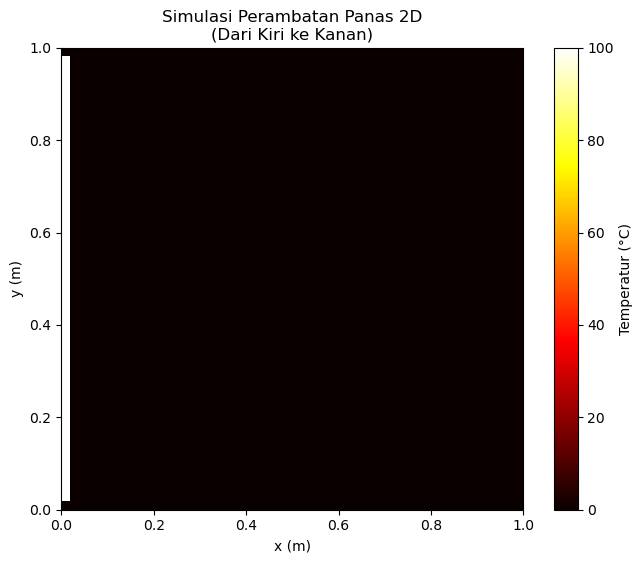

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameter fisika dan numerik
L = 1.0           # ukuran domain (meter)
N = 50            # jumlah grid dalam satu arah
alpha = 0.2       # konduktivitas termal
dx = dy = L / (N - 1)
dt = 0.4 * (dx**2) / (4 * alpha)  # CFL condition: dt <= dx²/(4α)
total_time = 0.5  # simulasi sampai 0.5 detik
steps = int(total_time / dt)

print(f"Δt = {dt:.6f}, total steps = {steps}")

# Inisialisasi temperatur
T = np.zeros((N, N))

# Syarat batas Dirichlet
T[:, 0] = 100.0   # sisi kiri = 100°C
T[:, -1] = 0.0    # sisi kanan = 0°C
T[0, :] = 0.0     # sisi atas = 0°C
T[-1, :] = 0.0    # sisi bawah = 0°C

# Simpan frame untuk animasi
frames = [T.copy()]

# Iterasi waktu
for n in range(steps):
    T_new = T.copy()
    
    # Update titik internal (tidak termasuk batas)
    for i in range(1, N-1):
        for j in range(1, N-1):
            T_new[i, j] = T[i, j] + alpha * dt / dx**2 * (
                T[i+1, j] - 2*T[i, j] + T[i-1, j] +
                T[i, j+1] - 2*T[i, j] + T[i, j-1]
            )
    
    T = T_new
    
    # Terapkan ulang syarat batas (penting!)
    T[:, 0] = 100.0
    T[:, -1] = 0.0
    T[0, :] = 0.0
    T[-1, :] = 0.0
    
    # Simpan frame setiap 5 langkah untuk animasi lebih cepat
    if n % 5 == 0:
        frames.append(T.copy())

print("Simulasi selesai.")

# Animasi
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(frames[0], cmap='hot', origin='lower', extent=[0, L, 0, L])
plt.colorbar(im, label='Temperatur (°C)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Simulasi Perambatan Panas 2D\n(Dari Kiri ke Kanan)')

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=100, blit=True)

# Tampilkan animasi
plt.show()

# Opsi: Simpan sebagai video (uncomment jika ingin menyimpan)
ani.save('simulasi_hantaran_panas_2d.mp4', writer='ffmpeg', fps=10)